<a href="https://colab.research.google.com/github/tewei0328/teach-programming/blob/main/twtalk_prompt_colab_plot_tsmc_input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 專案：台積電股價走勢分析工具

## 1. 開發計畫 (Plan)
- **目標**：從 Yahoo Finance 獲取台積電 (2330.TW) 過去一年的歷史數據並繪圖。
- **核心功能**：顯示每日收盤價走勢，並加入移動平均線以輔助判斷 [6, 7]。

## 2. 技術規格 (Technical Plan)
- **語言**：Python 3.x
- **套件**：`yfinance` (下載數據)、`pandas` (處理表格)、`matplotlib` (繪圖) [6, 8]。
- **Ticker**：優先使用 `2330.TW` (台股)。

## 3. 執行規則與決策 (Shipping Decisions)
- **數據清理**：必須處理缺失值 (`dropna()`) 以確保繪圖連續 [9]。
- **視覺化規範**：圖表需包含標題、日期軸、價格軸（新台幣）及圖例。
- **避坑指引**：避免使用過時的 API 調用方式，確保符合最新 `yfinance` 語法 [6]。

In [ ]:
with open('/content/project1.md', 'r') as f:
    project_md_content = f.read()
print(project_md_content)

FileNotFoundError: [Errno 2] No such file or directory: '/content/project1.md'

In [ ]:
import yfinance as yf
import pandas as pd

ts_ticker = '2330.TW'

# 下載台積電過去一年的歷史數據
ts_data = yf.download(ts_ticker, period='1y')

# 顯示數據的前幾行
display(ts_data.head())

/tmp/ipykernel_594/2036331192.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ts_data = yf.download(ts_ticker, period='1y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,2330.TW,2330.TW,2330.TW,2330.TW,2330.TW
Date,,,,,
2025-03-12,972.119263,979.006747,960.312146,964.247852,34184887
2025-03-13,949.489014,988.846071,949.489014,983.926439,37035693
2025-03-14,943.585449,953.424714,939.649743,949.489008,34333748
2025-03-17,954.408569,969.167465,952.440717,961.296054,31491061
2025-03-18,959.845459,966.765045,956.879922,964.788021,21575327


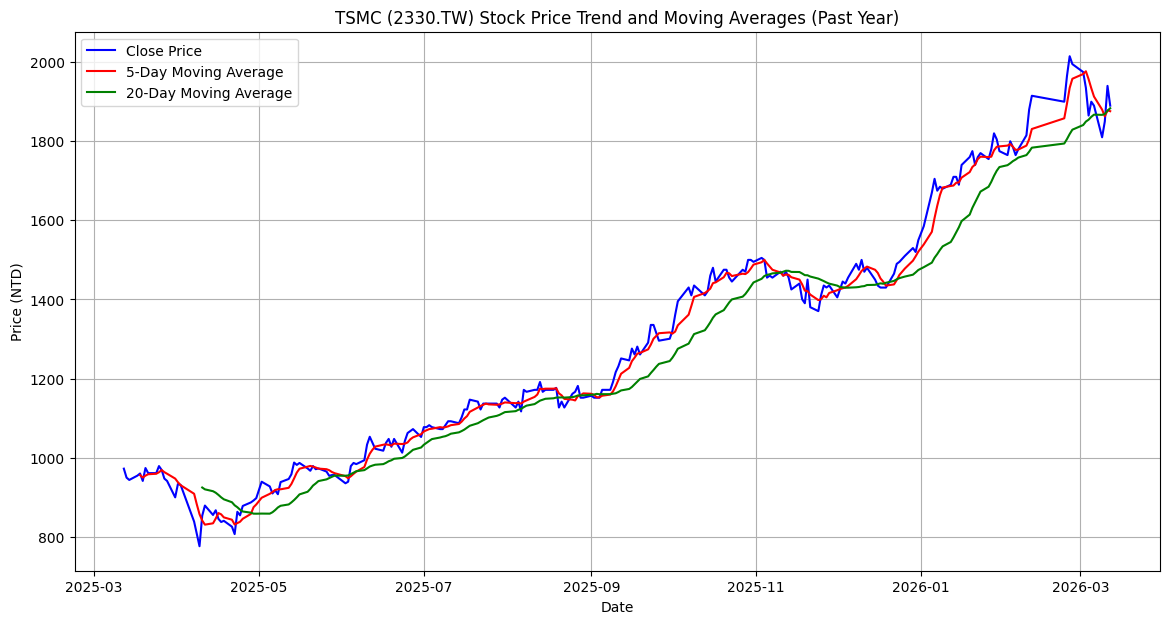

In [ ]:
import matplotlib.pyplot as plt

# 計算移動平均線
ts_data['MA5'] = ts_data[('Close', ts_ticker)].rolling(window=5).mean()
ts_data['MA20'] = ts_data[('Close', ts_ticker)].rolling(window=20).mean()

# 繪製股價走勢圖
plt.figure(figsize=(14, 7))
plt.plot(ts_data.index, ts_data[('Close', ts_ticker)], label='Close Price', color='blue')
plt.plot(ts_data.index, ts_data['MA5'], label='5-Day Moving Average', color='red')
plt.plot(ts_data.index, ts_data['MA20'], label='20-Day Moving Average', color='green')

# 添加圖表標題和標籤
plt.title('TSMC (2330.TW) Stock Price Trend and Moving Averages (Past Year)')
plt.xlabel('Date')
plt.ylabel('Price (NTD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# 檢查 DataFrame 的總行數
print(f"DataFrame 的總行數: {len(ts_data)}")

# 檢查 'MA5' 和 'MA20' 列的非空值數量
print(f"'MA5' 列的非空值數量: {ts_data['MA5'].count()}")
print(f"'MA20' 列的非空值數量: {ts_data['MA20'].count()}")

# 顯示 'MA5' 和 'MA20' 列的前25個值，以確認 NaN 的情況
display(ts_data[['MA5', 'MA20']].head(25))

DataFrame 的總行數: 243
'MA5' 列的非空值數量: 239
'MA20' 列的非空值數量: 224


Price,MA5,MA20
Ticker,,
Date,,
2025-03-12,NaN,NaN
2025-03-13,NaN,NaN
2025-03-14,NaN,NaN
2025-03-17,NaN,NaN
2025-03-18,955.889551,NaN
2025-03-19,949.678442,NaN
2025-03-20,954.517566,NaN
2025-03-21,957.967273,NaN


請用 Python 撰寫一個程式碼，使用 `yfinance` 函式庫下載台灣積體電路製造股份有限公司 (TSMC)，股票代號為 '2330.TW'，過去一年的歷史股價數據。

程式碼需求如下：
1.  **數據下載**：使用 `yfinance` 下載 '2330.TW' 過去一年的所有歷史數據。
2.  **數據處理**：
    *   計算 5 日移動平均線 (MA5) 和 20 日移動平均線 (MA20)，並將結果儲存為新的欄位。
    *   請注意 `yfinance` 可能返回帶有多重索引的 DataFrame，請確保正確存取 'Close' 價格欄位。
3.  **數據視覺化**：
    *   使用 `matplotlib` 繪製股價走勢圖。
    *   圖表中需包含：
        *   收盤價 (Close Price)
        *   5 日移動平均線 (5-Day Moving Average)
        *   20 日移動平均線 (20-Day Moving Average)
    *   圖表標題為 'TSMC (2330.TW) Stock Price Trend and Moving Averages (Past Year)'。
    *   X 軸標籤為 'Date'，Y 軸標籤為 'Price (NTD)'。
    *   顯示圖例 (Legend) 和格線 (Grid)。
    *   所有標籤和標題需使用英文。
4.  **輸出**：顯示下載數據的前幾行，並最終顯示繪製的股價走勢圖。


請輸入股票代碼 (例如: 2330 或 0050): 2330


/tmp/ipykernel_204/592618272.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, period='1y')
[*********************100%***********************]  1 of 1 completed

正在下載 2330.TW 的歷史數據...


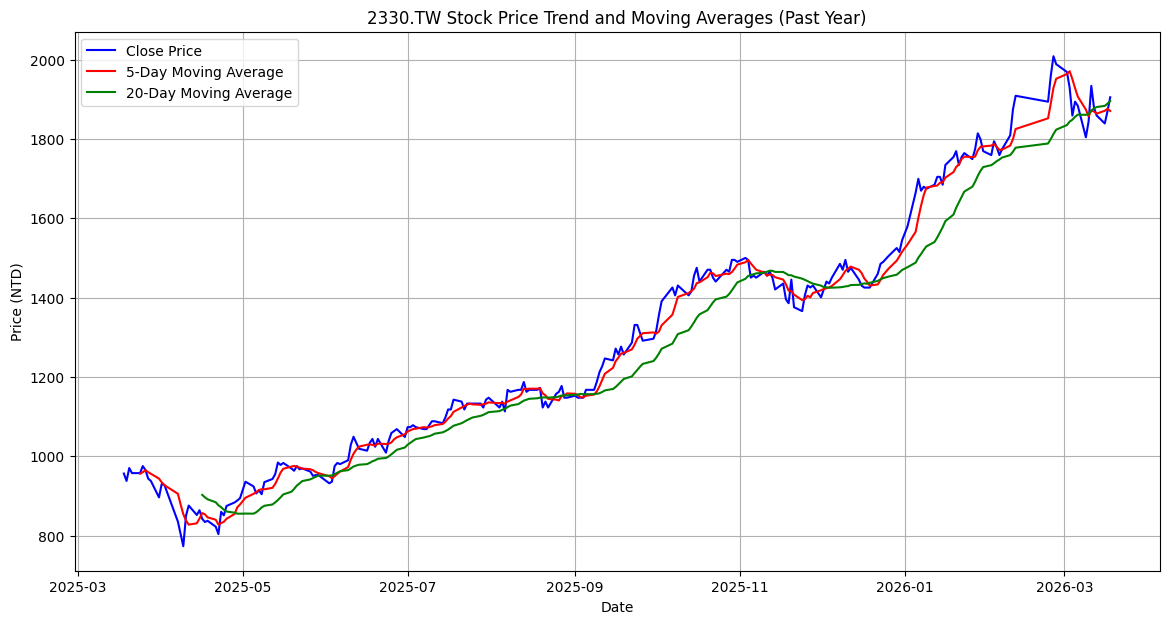

2330.TW 股價走勢圖已繪製完成。


Price,Close,High,Low,Open,Volume
Ticker,2330.TW,2330.TW,2330.TW,2330.TW,2330.TW
Date,,,,,
2025-03-18,956.723999,963.621082,953.768106,961.650487,21575327
2025-03-19,938.003357,952.782822,936.032762,950.812226,35245036
2025-03-20,970.518188,970.518188,956.724021,963.621105,28715956
2025-03-21,957.709290,972.488754,955.738694,970.518159,39214916
2025-03-24,957.709290,972.488754,957.709290,971.503456,16121506


In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

def plot_stock_trend(ticker):
    """
    下載指定股票代碼的歷史數據，計算移動平均線並繪製股價走勢圖。
    """
    print(f"正在下載 {ticker} 的歷史數據...")
    try:
        stock_data = yf.download(ticker, period='1y')

        if stock_data.empty:
            print(f"找不到股票代碼 {ticker} 的數據，請檢查代碼是否正確。")
            return

        # 確保 'Close' 價格欄位在多重索引中被正確存取
        if isinstance(stock_data.columns, pd.MultiIndex):
            if ('Close', ticker) in stock_data.columns:
                close_prices = stock_data[('Close', ticker)]
            elif 'Close' in stock_data.columns:
                # fallback for single-level index if yfinance changes behavior
                close_prices = stock_data['Close']
            else:
                print("無法找到 'Close' 價格欄位。")
                return
        else:
            close_prices = stock_data['Close']

        # 數據清理：處理缺失值 (主要處理 yfinance 在非交易日可能返回的 NaN)
        close_prices = close_prices.dropna()

        # 計算移動平均線
        ma5 = close_prices.rolling(window=5).mean()
        ma20 = close_prices.rolling(window=20).mean()

        # 繪製股價走勢圖
        plt.figure(figsize=(14, 7))
        plt.plot(close_prices.index, close_prices, label='Close Price', color='blue')
        plt.plot(ma5.index, ma5, label='5-Day Moving Average', color='red')
        plt.plot(ma20.index, ma20, label='20-Day Moving Average', color='green')

        # 添加圖表標題和標籤
        plt.title(f'{ticker} Stock Price Trend and Moving Averages (Past Year)')
        plt.xlabel('Date')
        plt.ylabel('Price (NTD)')
        plt.legend()
        plt.grid(True)
        plt.show()

        print(f"{ticker} 股價走勢圖已繪製完成。")
        display(stock_data.head())

    except Exception as e:
        print(f"處理 {ticker} 時發生錯誤: {e}")

# 交互式輸入介面
user_ticker = input("請輸入股票代碼 (例如: 2330 或 0050): ")

# 自動判斷並添加 '.TW' 後綴
formatted_ticker = user_ticker.upper()
if not formatted_ticker.endswith('.TW'):
    formatted_ticker += '.TW'

plot_stock_trend(formatted_ticker) # 使用格式化後的股票代碼